In [32]:
import sys
sys.path.insert(1, "/Users/madalina/Documents/M2TAL/stage/check_coherent_labels/tod")

import tod.corpus
import tod.outliers
import tod.clustering
import tod.plotting

corpus = tod.corpus.Corpus(
    treebank_path="/Users/madalina/Documents/M1TAL/stage-SK/Treebanks/UD_French-GSD-master",
    grew_pattern="pattern {X[upos=ADV]} without {X[InIdiom=Yes];X[Idiom=Yes]}",
    patterns_text_file="../3. probability_matrix/patterns_adv.txt",
    matrix_type="coverage"
)

Number of matches after filtering: 11701


In [2]:
import numpy as np
with open('x_65dims.npy', 'rb') as f:
    X = np.load(f)

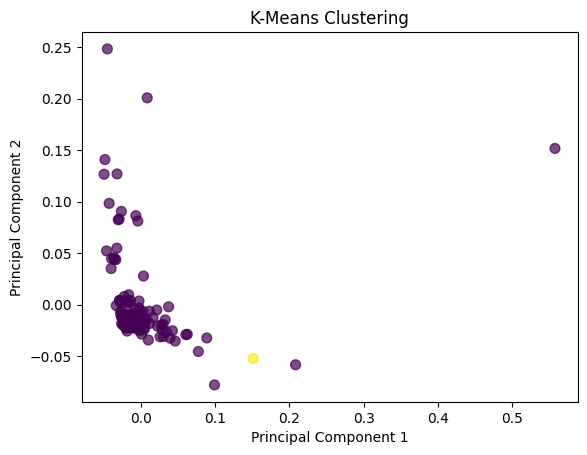

In [33]:
from sklearn.cluster import KMeans
import numpy as np
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Perform K-Means clustering
kmeans = KMeans(n_clusters=2, random_state=42)  # Adjust n_clusters as needed
labels = kmeans.fit_predict(X)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)
# Visualize the clusters (using PCA for 2D projection)
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels, cmap='viridis', s=50, alpha=0.7)
plt.title("K-Means Clustering")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.show()

In [34]:
types_of_matrix = ["precision", "coverage", "PMI", "tf-idf", "geometric_mean"]
red_dims = {}
for type_of_matrix in types_of_matrix:
    with open(f"{type_of_matrix}_reduced_dims.npy", 'rb') as f:
        X = np.load(f)
    kmeans = KMeans(n_clusters=2, random_state=42)  # Adjust n_clusters as needed
    labels = kmeans.fit_predict(X)
    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(X)
    red_dims[type_of_matrix] = [X_pca[:, 0], X_pca[:, 1], labels]

In [35]:
types_of_matrix = ["precision", "coverage", "PMI", "tf-idf", "geometric_mean"]
orig_dims = {}
for type_of_matrix in types_of_matrix:
    with open(f"{type_of_matrix}_orig_dims.npy", 'rb') as f:
        X = np.load(f)
    kmeans = KMeans(n_clusters=2, random_state=42)  # Adjust n_clusters as needed
    labels = kmeans.fit_predict(X)
    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(X)
    orig_dims[type_of_matrix] = [X_pca[:, 0], X_pca[:, 1], labels]

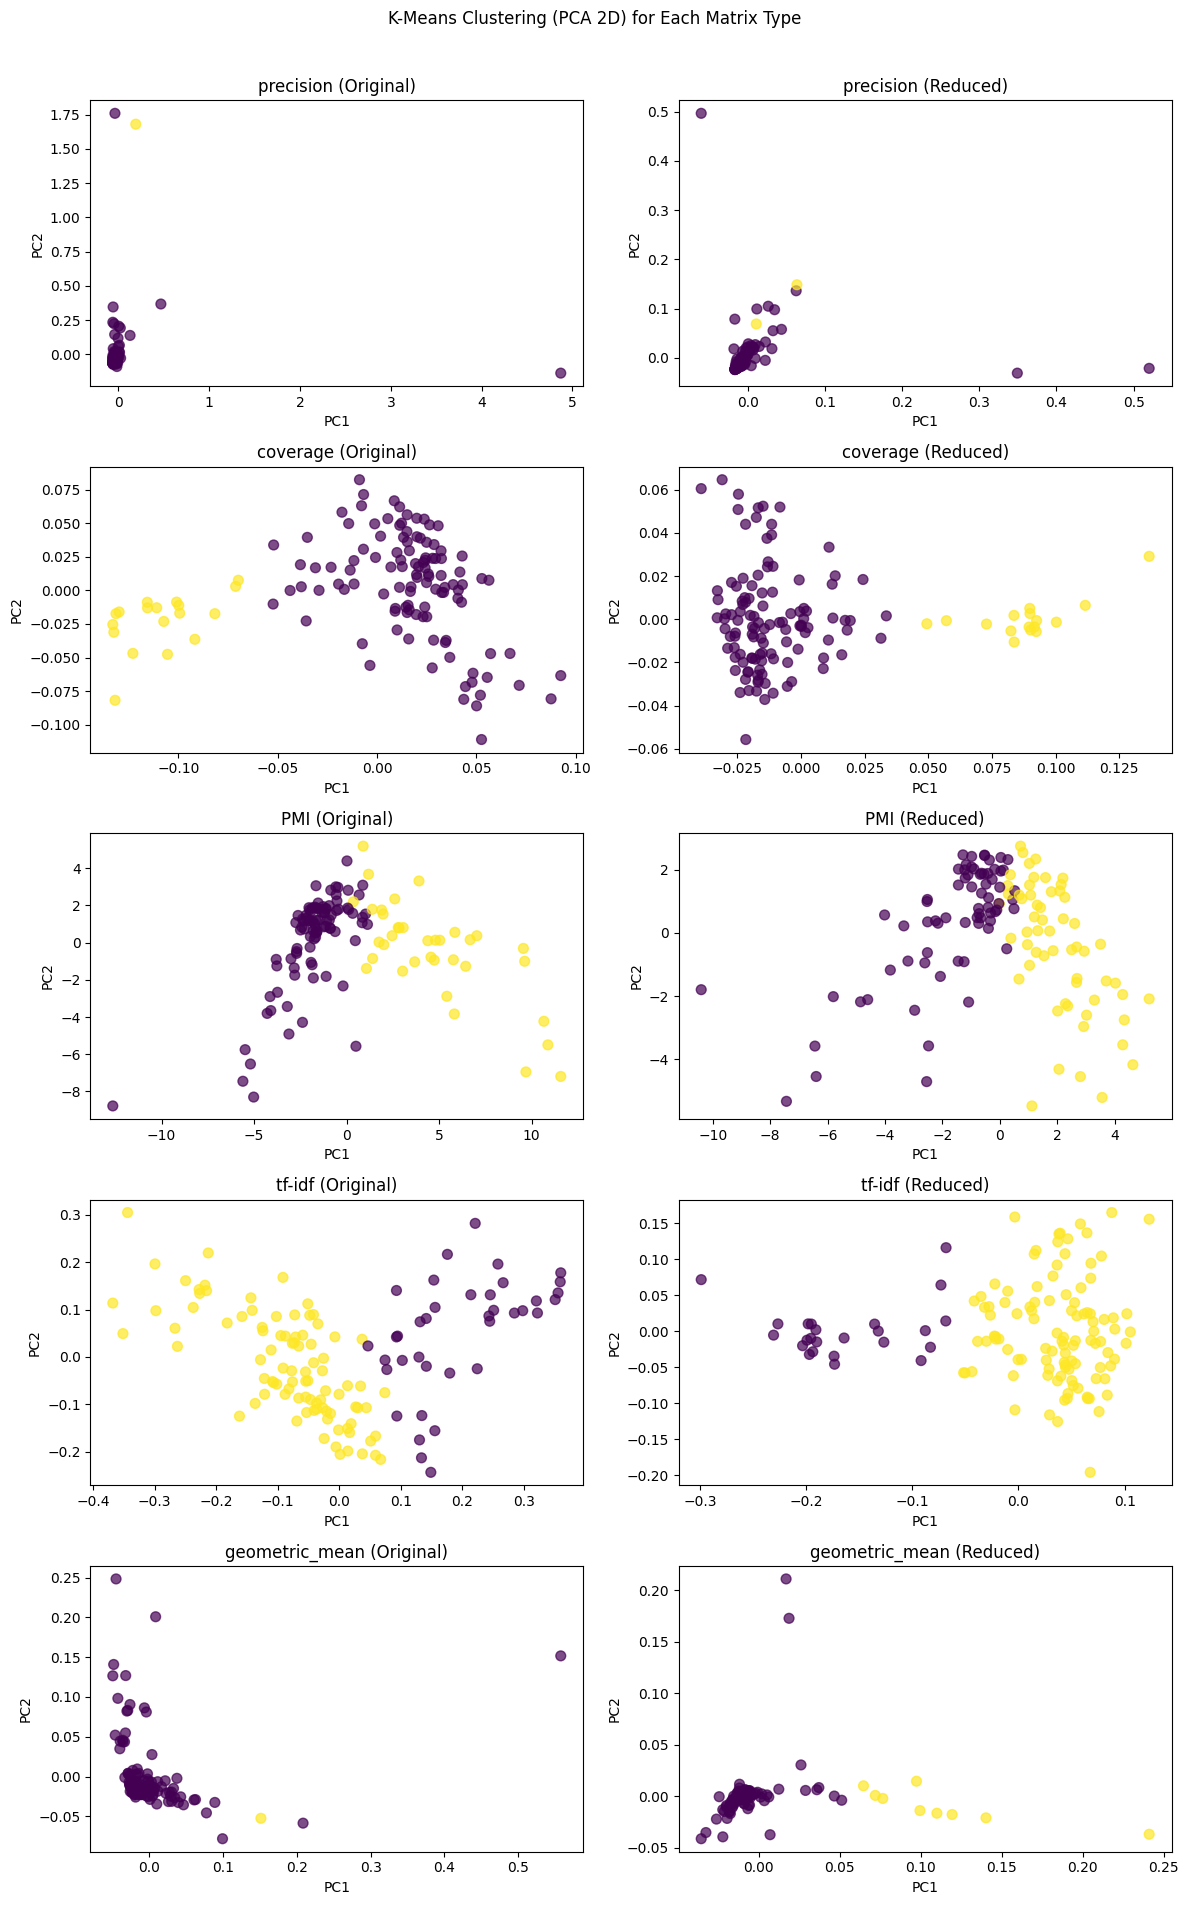

In [36]:
fig, axes = plt.subplots(nrows=5, ncols=2, figsize=(12, 20))
fig.suptitle("K-Means Clustering (PCA 2D) for Each Matrix Type", fontsize=12)

for i, matrix_type in enumerate(types_of_matrix):
    # Original data
    x0, x1, labels = orig_dims[matrix_type]
    ax = axes[i, 0]
    scatter = ax.scatter(x0, x1, c=labels, cmap='viridis', s=50, alpha=0.7)
    ax.set_title(f"{matrix_type} (Original)")
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")
    
    # Reduced data
    x0, x1, labels = red_dims[matrix_type]
    ax = axes[i, 1]
    scatter = ax.scatter(x0, x1, c=labels, cmap='viridis', s=50, alpha=0.7)
    ax.set_title(f"{matrix_type} (Reduced)")
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")

plt.tight_layout(rect=[0, 0.03, 1, 0.97])
plt.show()

In [11]:
red_dims['precision'][2]

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0],
      dtype=int32)

In [14]:
type(red_dims['precision'])

list

In [37]:
red_dims_dict = {}
for matrix_type in types_of_matrix:
    red_dims_dict[matrix_type] = {}
    labels = red_dims[matrix_type][2]
    red_dims_dict[matrix_type]["clusters"] = {}
    for i in range(len(labels)):
        if labels[i] not in red_dims_dict[matrix_type]["clusters"]:
            red_dims_dict[matrix_type]["clusters"][labels[i]] = []
        red_dims_dict[matrix_type]["clusters"][labels[i]].append(corpus.idx2lexunit(i))

In [38]:
result = {}

for matrix_type, matrix_data in red_dims_dict.items():
    for cluster_id, adverbs in matrix_data['clusters'].items():
        for adverb, pos in adverbs:
            key = (adverb, pos)
            if key not in result:
                result[key] = {}
            result[key][matrix_type] = cluster_id

print(r"\begin{tabular}{l" + "c" * len(types_of_matrix) + "}")
print(r"\textbf{(Adverb, POS)} & " + " & ".join(r"\textbf{" + mt.capitalize() + "}" for mt in types_of_matrix) + r" \\ \hline")

for key in sorted(result):
    row = [f"{key}"]
    for mt in types_of_matrix:
        row.append(str(result[key].get(mt, "")))
    print(" & ".join(row) + r" \\")
print(r"\end{tabular}")

\begin{tabular}{lccccc}
\textbf{(Adverb, POS)} & \textbf{Precision} & \textbf{Coverage} & \textbf{Pmi} & \textbf{Tf-idf} & \textbf{Geometric_mean} \\ \hline
('absolument', 'ADV') & 0 & 0 & 0 & 1 & 0 \\
('actuellement', 'ADV') & 0 & 0 & 0 & 1 & 0 \\
('afin', 'ADV') & 0 & 0 & 1 & 0 & 0 \\
('ailleurs', 'ADV') & 0 & 0 & 1 & 1 & 0 \\
('ainsi', 'ADV') & 0 & 0 & 0 & 1 & 0 \\
('alors', 'ADV') & 0 & 0 & 0 & 1 & 0 \\
('après', 'ADV') & 0 & 0 & 1 & 1 & 0 \\
('assez', 'ADV') & 0 & 0 & 1 & 1 & 0 \\
('au-delà', 'ADV') & 0 & 1 & 1 & 0 & 0 \\
('au-dessus', 'ADV') & 0 & 1 & 1 & 0 & 0 \\
("aujourd'hui", 'ADV') & 0 & 0 & 0 & 1 & 0 \\
('auparavant', 'ADV') & 0 & 0 & 1 & 1 & 0 \\
('auprès', 'ADV') & 0 & 1 & 1 & 0 & 1 \\
('aussi', 'ADV') & 0 & 0 & 0 & 1 & 0 \\
('autant', 'ADV') & 0 & 0 & 1 & 1 & 0 \\
('autant', 'PRON') & 0 & 1 & 1 & 0 & 0 \\
('autour', 'ADV') & 0 & 1 & 1 & 0 & 1 \\
('autrement', 'ADV') & 0 & 0 & 0 & 1 & 0 \\
('avant', 'ADV') & 0 & 0 & 1 & 0 & 0 \\
('beaucoup', 'ADV') & 0 & 0 & 0 & 1 & 0 \\


In [24]:
result.keys()

dict_keys([('absolument', 'ADV'), ('actuellement', 'ADV'), ('afin', 'ADV'), ('ailleurs', 'ADV'), ('ainsi', 'ADV'), ('alors', 'ADV'), ('après', 'ADV'), ('assez', 'ADV'), ('au-delà', 'ADV'), ('au-dessus', 'ADV'), ("aujourd'hui", 'ADV'), ('auparavant', 'ADV'), ('auprès', 'ADV'), ('aussi', 'ADV'), ('autant', 'ADV'), ('autant', 'PRON'), ('autour', 'ADV'), ('autrement', 'ADV'), ('avant', 'ADV'), ('beaucoup', 'ADV'), ('beaucoup', 'PRON'), ('bien', 'ADV'), ('bientôt', 'ADV'), ('cependant', 'ADV'), ('certes', 'ADV'), ('clairement', 'ADV'), ('comment', 'ADV'), ('complètement', 'ADV'), ('contrairement', 'ADV'), ('davantage', 'ADV'), ('depuis', 'ADV'), ('directement', 'ADV'), ('donc', 'ADV'), ('définitivement', 'ADV'), ('déjà', 'ADV'), ('désormais', 'ADV'), ('encore', 'ADV'), ('enfin', 'ADV'), ('ensemble', 'ADV'), ('ensuite', 'ADV'), ('entièrement', 'ADV'), ('environ', 'ADV'), ('essentiellement', 'ADV'), ('extrêmement', 'ADV'), ('facilement', 'ADV'), ('finalement', 'ADV'), ('fort', 'ADV'), ('forte

In [43]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Assume `result` is built as before
adverbs = sorted(result.keys())
n = len(adverbs)
matrix_types = list(red_dims_dict.keys())

# Initialize similarity matrix
sim_matrix = np.zeros((n, n), dtype=int)

for i, adv1 in enumerate(adverbs):
    for j, adv2 in enumerate(adverbs):
        count = 0
        for mt in matrix_types:
            if result[adv1].get(mt) == result[adv2].get(mt) and mt in result[adv1] and mt in result[adv2]:
                count += 1
        sim_matrix[i, j] = count

# Prepare labels
labels = [f"{a}" for a in adverbs]  # or f"{a[0]} ({a[1]})" for full label

# Plot heatmap


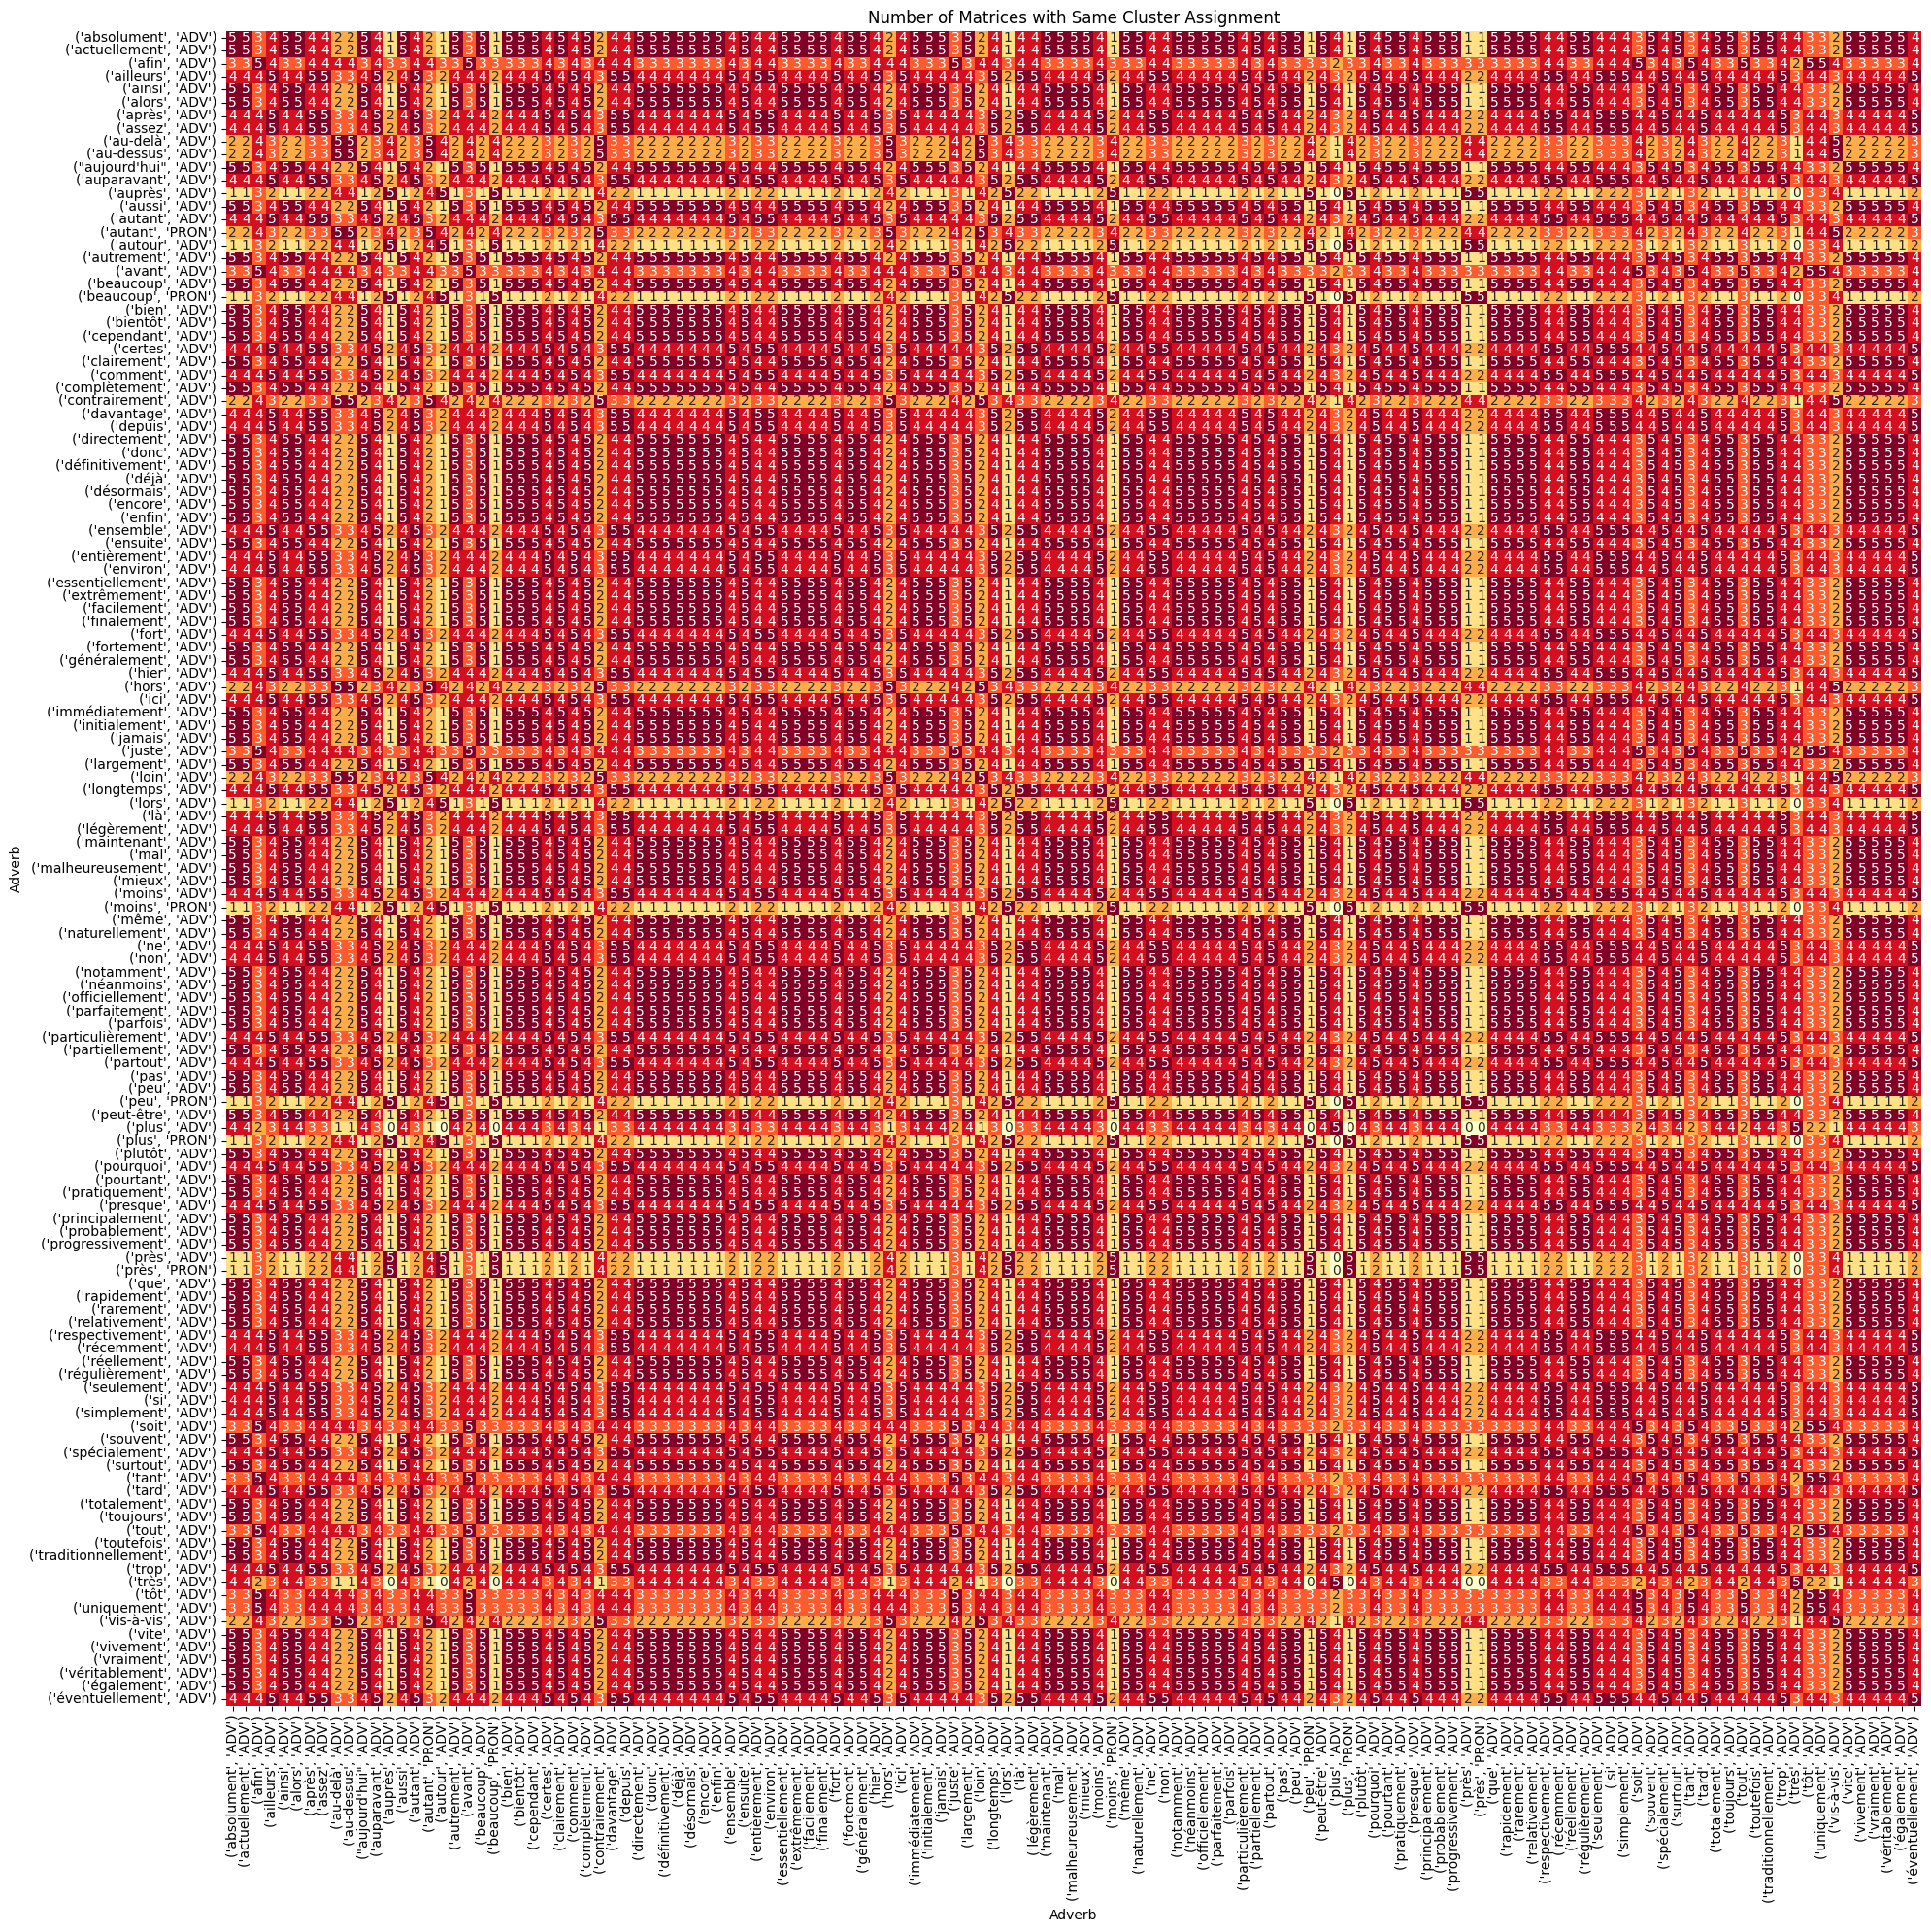

In [44]:
plt.figure(figsize=(20, 20))
# plt.figure(figsize=(12, 12))
sns.heatmap(sim_matrix, annot=True, fmt="d", xticklabels=labels, yticklabels=labels, cmap="YlOrRd", cbar=False)
plt.xlabel("Adverb")
plt.ylabel("Adverb")
plt.title("Number of Matrices with Same Cluster Assignment")
plt.tight_layout()
plt.show()

In [45]:
# get the points of the clusters
clusters = {}
for i in range(len(labels)):
    if labels[i] not in clusters:
        clusters[labels[i]] = []
    clusters[labels[i]].append(corpus.idx2lexunit(i))

In [46]:
clusters

{"('absolument', 'ADV')": [('absolument', 'ADV')],
 "('actuellement', 'ADV')": [('actuellement', 'ADV')],
 "('afin', 'ADV')": [('afin', 'ADV')],
 "('ailleurs', 'ADV')": [('ailleurs', 'ADV')],
 "('ainsi', 'ADV')": [('ainsi', 'ADV')],
 "('alors', 'ADV')": [('alors', 'ADV')],
 "('après', 'ADV')": [('après', 'ADV')],
 "('assez', 'ADV')": [('assez', 'ADV')],
 "('au-delà', 'ADV')": [('au-delà', 'ADV')],
 "('au-dessus', 'ADV')": [('au-dessus', 'ADV')],
 '("aujourd\'hui", \'ADV\')': [("aujourd'hui", 'ADV')],
 "('auparavant', 'ADV')": [('auparavant', 'ADV')],
 "('auprès', 'ADV')": [('auprès', 'ADV')],
 "('aussi', 'ADV')": [('aussi', 'ADV')],
 "('autant', 'ADV')": [('autant', 'ADV')],
 "('autant', 'PRON')": [('autant', 'PRON')],
 "('autour', 'ADV')": [('autour', 'ADV')],
 "('autrement', 'ADV')": [('autrement', 'ADV')],
 "('avant', 'ADV')": [('avant', 'ADV')],
 "('beaucoup', 'ADV')": [('beaucoup', 'ADV')],
 "('beaucoup', 'PRON')": [('beaucoup', 'PRON')],
 "('bien', 'ADV')": [('bien', 'ADV')],
 "(

# Cluster compactness and separation
## Dunn's index

In [47]:
from scipy.spatial.distance import pdist
from scipy.cluster.hierarchy import linkage

distance_matrix = pdist(X, metric="euclidean")
linked = linkage(
            distance_matrix, method='average', optimal_ordering=True
        )

In [48]:
from scipy.cluster.hierarchy import fcluster

def delta(ck, cl):
    values = np.ones([len(ck), len(cl)])*10000
    
    for i in range(0, len(ck)):
        for j in range(0, len(cl)):
            values[i, j] = np.linalg.norm(ck[i]-cl[j])
            
    return np.min(values)
    
def big_delta(ci):
    values = np.zeros([len(ci), len(ci)])
    
    for i in range(0, len(ci)):
        for j in range(0, len(ci)):
            values[i, j] = np.linalg.norm(ci[i]-ci[j])
            
    return np.max(values)
    
def dunn(k_list):
    """ Dunn index [CVI]
    
    Parameters
    ----------
    k_list : list of np.arrays
        A list containing a numpy array for each cluster |c| = number of clusters
        c[K] is np.array([N, p]) (N : number of samples in cluster K, p : sample dimension)
    """
    deltas = np.ones([len(k_list), len(k_list)])*1000000
    big_deltas = np.zeros([len(k_list), 1])
    l_range = list(range(0, len(k_list)))
    
    for k in l_range:
        for l in (l_range[0:k]+l_range[k+1:]):
            deltas[k, l] = delta(k_list[k], k_list[l])
        
        big_deltas[k] = big_delta(k_list[k])

    di = np.min(deltas)/np.max(big_deltas)
    return di

# Calculate the Dunn index
hierarchical_dunn_scores = []
cluster_range = range(2, 11)  # Adjust the range as needed
for i in cluster_range:
    labels = fcluster(linked, i, criterion='maxclust')
    clusters = [X[labels == j] for j in np.unique(labels)]
    score = dunn(clusters)
    # print(f'Number of clusters: {i}, Dunn Index: {score}')
    hierarchical_dunn_scores.append(score)


In [49]:
import numpy as np
from scipy.spatial.distance import pdist
from scipy.cluster.hierarchy import linkage
types_of_matrix = ["precision", "coverage", "PMI", "tf-idf", "geometric_mean"]
link = ['single', 'average', 'complete']
red_dims = {}
for type_of_matrix in types_of_matrix:
    red_dims[type_of_matrix] = {}
    with open(f"{type_of_matrix}_reduced_dims.npy", 'rb') as f:
        X = np.load(f)
    red_dims[type_of_matrix]['cosine']= {}
    distance_matrix = pdist(X, metric="cosine")
    for i in range(len(link)):
        red_dims[type_of_matrix]['cosine'][link[i]] = {}
        linked = linkage(
            distance_matrix, method=link[i], optimal_ordering=True
        )
        for h in cluster_range:
            labels = fcluster(linked, h, criterion='maxclust')
            clusters = [X[labels == j] for j in np.unique(labels)]
            score = dunn(clusters)  
            red_dims[type_of_matrix]['cosine'][link[i]][h] = score

In [50]:
link = ['single', 'average', 'ward', 'complete', 'centroid']
for type_of_matrix in types_of_matrix:
    with open(f"{type_of_matrix}_reduced_dims.npy", 'rb') as f:
        X = np.load(f)
    red_dims[type_of_matrix]['euclidean']= {}
    distance_matrix = pdist(X, metric="euclidean")
    for i in range(len(link)):
        red_dims[type_of_matrix]['euclidean'][link[i]] = {}
        linked = linkage(
            distance_matrix, method=link[i], optimal_ordering=True
        )  
        for h in cluster_range:
            labels = fcluster(linked, h, criterion='maxclust')
            clusters = [X[labels == j] for j in np.unique(labels)]
            score = dunn(clusters)  
            red_dims[type_of_matrix]['euclidean'][link[i]][h] = score

In [51]:
import numpy as np
from scipy.spatial.distance import pdist
from scipy.cluster.hierarchy import linkage
types_of_matrix = ["precision", "coverage", "PMI", "tf-idf", "geometric_mean"]
link = ['single', 'average', 'complete']
orig_dims = {}
for type_of_matrix in types_of_matrix:
    orig_dims[type_of_matrix] = {}
    with open(f"{type_of_matrix}_orig_dims.npy", 'rb') as f:
        X = np.load(f)
    orig_dims[type_of_matrix]['cosine']= {}
    distance_matrix = pdist(X, metric="cosine")
    for i in range(len(link)):
        orig_dims[type_of_matrix]['cosine'][link[i]] = {}
        linked = linkage(
            distance_matrix, method=link[i], optimal_ordering=True
        )
        for h in cluster_range:
            labels = fcluster(linked, h, criterion='maxclust')
            clusters = [X[labels == j] for j in np.unique(labels)]
            score = dunn(clusters)  
            orig_dims[type_of_matrix]['cosine'][link[i]][h] = score

In [52]:
link = ['single', 'average', 'ward', 'complete', 'centroid']
for type_of_matrix in types_of_matrix:
    with open(f"{type_of_matrix}_orig_dims.npy", 'rb') as f:
        X = np.load(f)
    orig_dims[type_of_matrix]['euclidean']= {}
    distance_matrix = pdist(X, metric="euclidean")
    for i in range(len(link)):
        orig_dims[type_of_matrix]['euclidean'][link[i]] = {}
        linked = linkage(
            distance_matrix, method=link[i], optimal_ordering=True
        )  
        for h in cluster_range:
            labels = fcluster(linked, h, criterion='maxclust')
            clusters = [X[labels == j] for j in np.unique(labels)]
            score = dunn(clusters)  
            orig_dims[type_of_matrix]['euclidean'][link[i]][h] = score

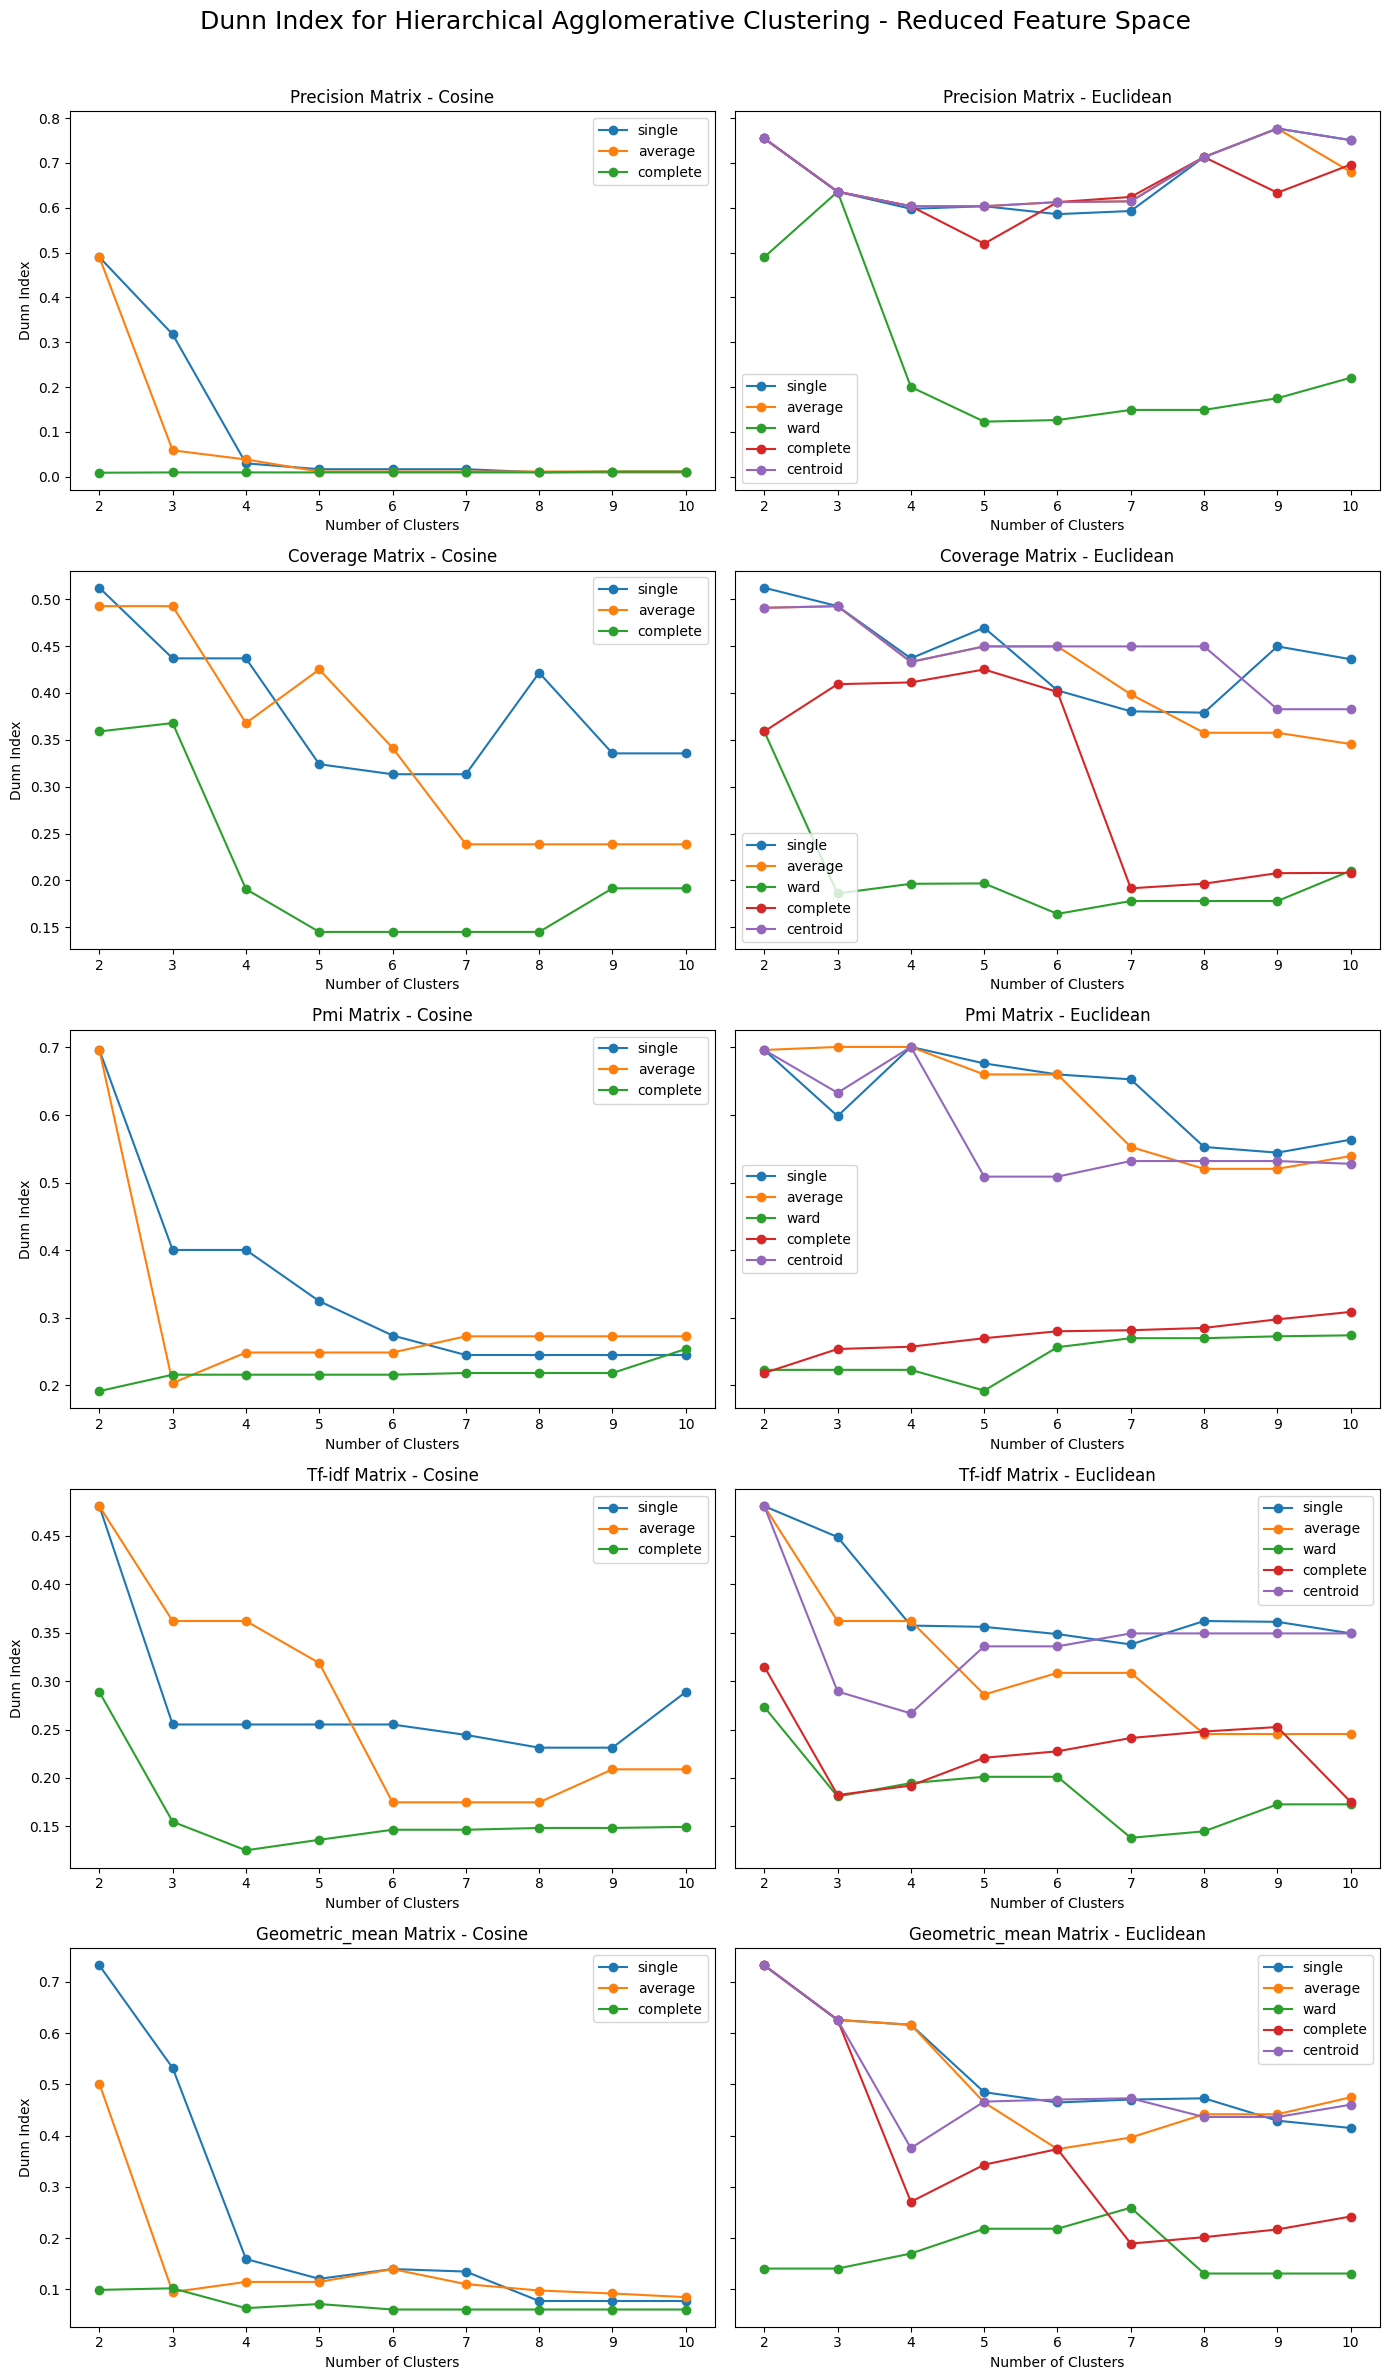

In [53]:
import matplotlib.pyplot as plt

matrix_types = list(red_dims.keys())
n_types = len(matrix_types)
fig, axes = plt.subplots(n_types, 2, figsize=(14, 5 * n_types), sharey='row')
fig.suptitle("Dunn Index for Hierarchical Agglomerative Clustering - Reduced Feature Space", fontsize=18)

for row, matrix_type in enumerate(matrix_types):
    metrics = red_dims[matrix_type]
    for col, metric in enumerate(['cosine', 'euclidean']):
        ax = axes[row, col] if n_types > 1 else axes[col]
        for linkage in metrics[metric]:
            dunn_scores = [metrics[metric][linkage].get(k, float('nan')) for k in cluster_range]
            ax.plot(cluster_range, dunn_scores, marker='o', label=linkage)
        ax.set_title(f"{matrix_type.capitalize()} Matrix - {metric.capitalize()}")
        ax.set_xlabel("Number of Clusters")
        if col == 0:
            ax.set_ylabel("Dunn Index")
        ax.legend()
plt.tight_layout(rect=[0, 0.03, 1, 0.97])
plt.show()

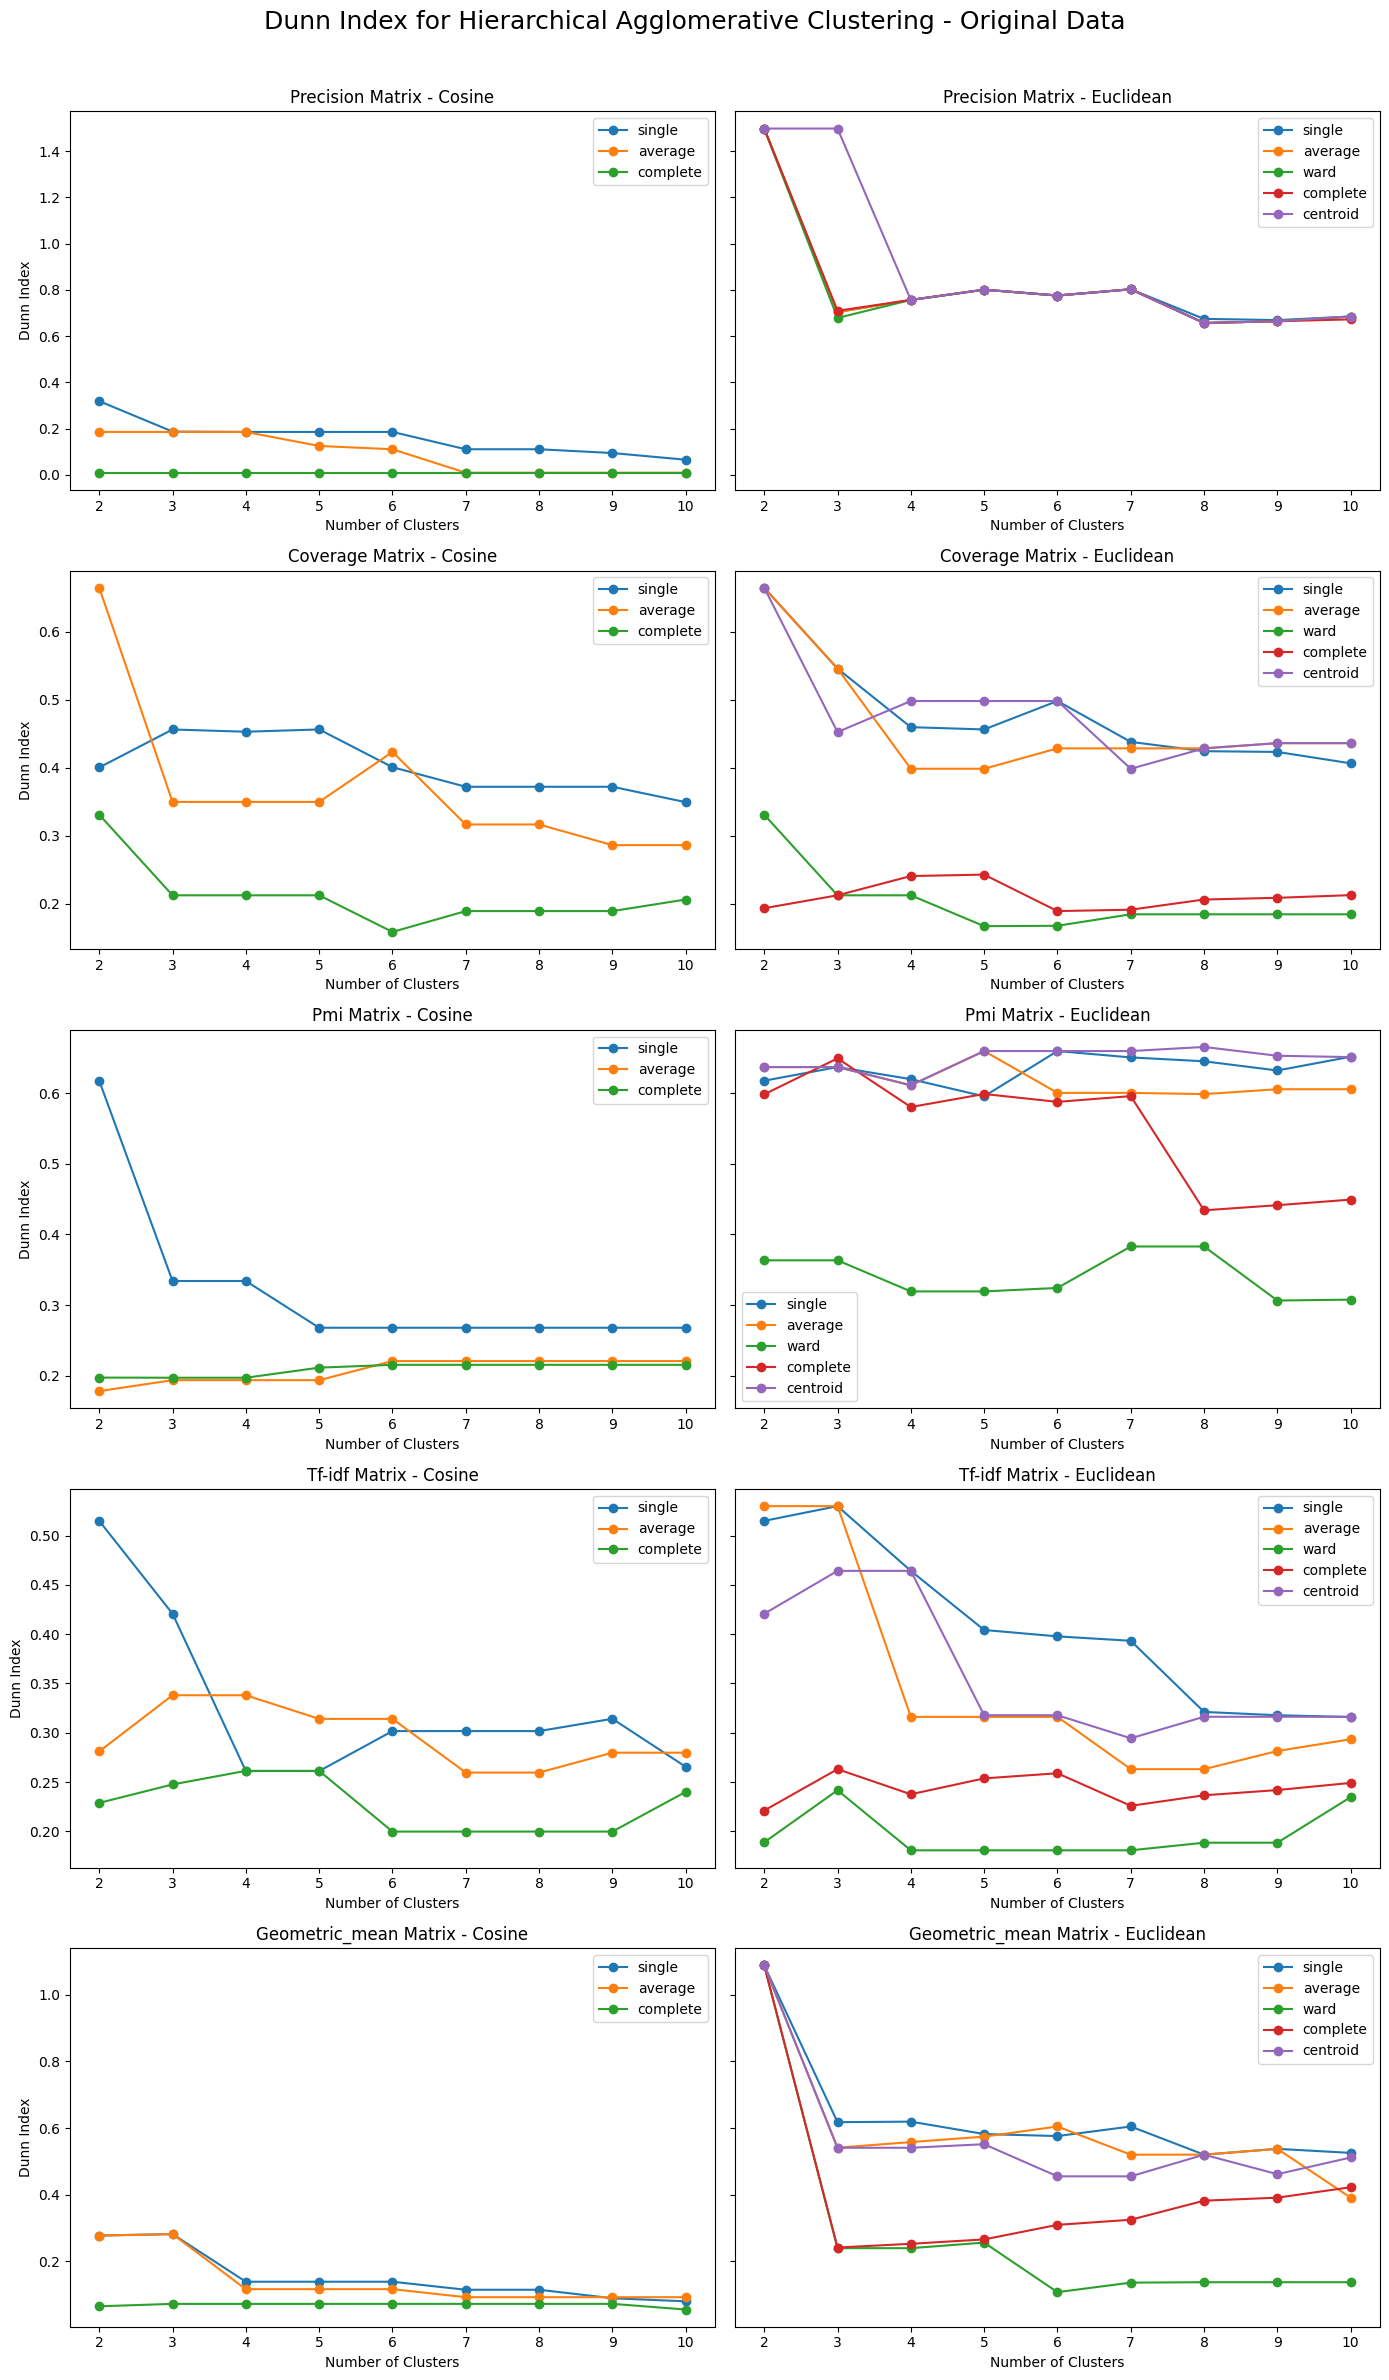

In [54]:
import matplotlib.pyplot as plt

matrix_types = list(orig_dims.keys())
n_types = len(matrix_types)
fig, axes = plt.subplots(n_types, 2, figsize=(14, 5 * n_types), sharey='row')
fig.suptitle("Dunn Index for Hierarchical Agglomerative Clustering - Original Data", fontsize=18)

for row, matrix_type in enumerate(matrix_types):
    metrics = orig_dims[matrix_type]
    for col, metric in enumerate(['cosine', 'euclidean']):
        ax = axes[row, col] if n_types > 1 else axes[col]
        for linkage in metrics[metric]:
            dunn_scores = [metrics[metric][linkage].get(k, float('nan')) for k in cluster_range]
            ax.plot(cluster_range, dunn_scores, marker='o', label=linkage)
        ax.set_title(f"{matrix_type.capitalize()} Matrix - {metric.capitalize()}")
        ax.set_xlabel("Number of Clusters")
        if col == 0:
            ax.set_ylabel("Dunn Index")
        ax.legend()
plt.tight_layout(rect=[0, 0.03, 1, 0.97])
plt.show()

In [55]:
from sklearn.cluster import KMeans

kmeans_dunn_scores = []
for i in cluster_range:
    kmeans = KMeans(n_clusters=i, random_state=42)  # Initialize K-Means
    labels = kmeans.fit_predict(X)  # Fit and predict cluster labels
    clusters = [X[labels == j] for j in np.unique(labels)]  # Group data points into clusters
    score = dunn(clusters)  # Calculate the Dunn Index
    kmeans_dunn_scores.append(score)

In [56]:
from sklearn.cluster import KMeans
orig_dims = {}
for type_of_matrix in types_of_matrix:
    orig_dims[type_of_matrix] = {}
    with open(f"{type_of_matrix}_orig_dims.npy", 'rb') as f:
        X = np.load(f)
    for i in cluster_range:
        kmeans = KMeans(n_clusters=i, random_state=42)  # Initialize K-Means
        labels = kmeans.fit_predict(X)  # Fit and predict cluster labels
        clusters = [X[labels == j] for j in np.unique(labels)]  # Group data points into clusters
        score = dunn(clusters)  # Calculate the Dunn Index
        orig_dims[type_of_matrix][i] = score

In [57]:
from sklearn.cluster import KMeans
red_dims = {}
for type_of_matrix in types_of_matrix:
    red_dims[type_of_matrix] = {}
    with open(f"{type_of_matrix}_reduced_dims.npy", 'rb') as f:
        X = np.load(f)
    for i in cluster_range:
        kmeans = KMeans(n_clusters=i, random_state=42)  # Initialize K-Means
        labels = kmeans.fit_predict(X)  # Fit and predict cluster labels
        clusters = [X[labels == j] for j in np.unique(labels)]  # Group data points into clusters
        score = dunn(clusters)  # Calculate the Dunn Index
        red_dims[type_of_matrix][i] = score

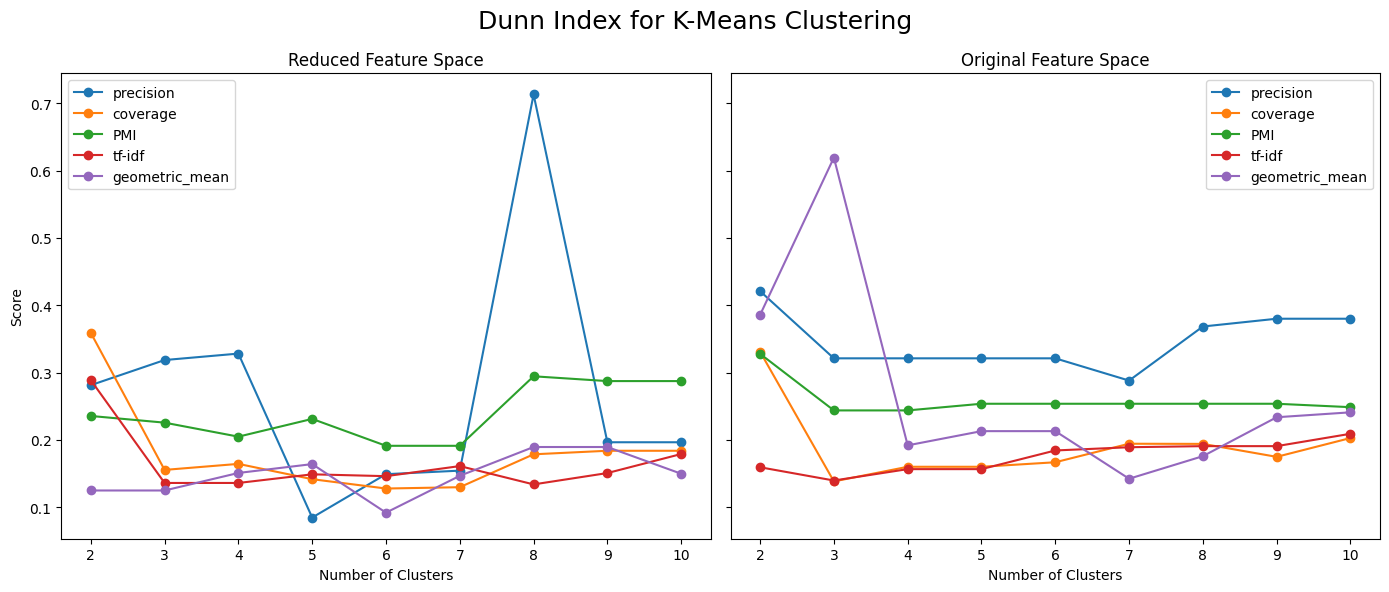

In [58]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)
titles = ["Reduced Feature Space", "Original Feature Space"]
dicts = [red_dims, orig_dims]
fig.suptitle("Dunn Index for K-Means Clustering", fontsize=18)
for ax, metric_dict, title in zip(axes, dicts, titles):
    for matrix_type, values in metric_dict.items():
        scores = [values.get(k, float('nan')) for k in range(2, 11)]
        ax.plot(range(2, 11), scores, marker='o', label=matrix_type)
    ax.set_title(title)
    ax.set_xlabel("Number of Clusters")
    ax.legend()
axes[0].set_ylabel("Score")
plt.tight_layout()
plt.show()

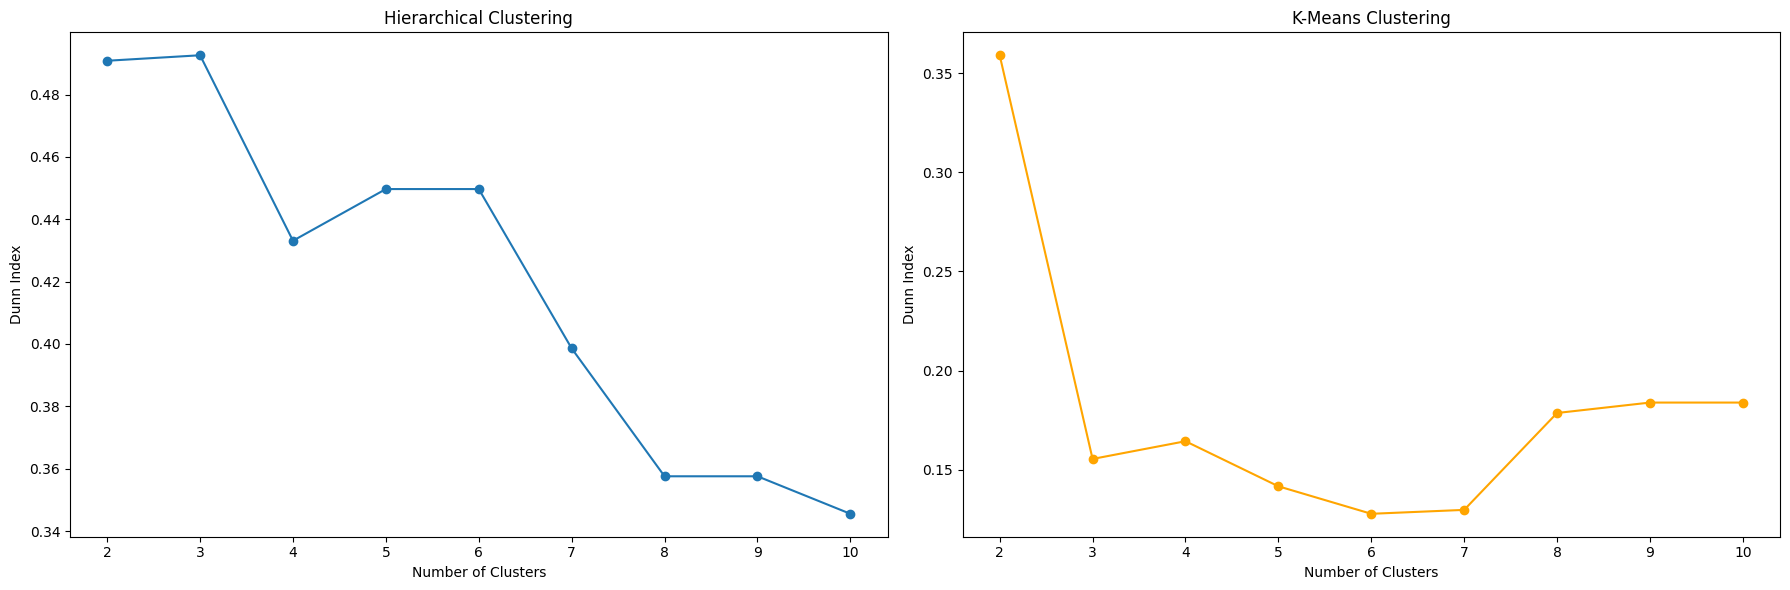

In [25]:
# Plot the Dunn Index for hierarchical clustering
fig, ax = plt.subplots(1, 2, figsize=(18, 6))  # Create 3 subplots for hierarchical, K-Means, and DBSCAN

# Hierarchical Clustering Dunn Index
ax[0].plot(cluster_range, hierarchical_dunn_scores, marker='o', label='Hierarchical')
ax[0].set_title('Hierarchical Clustering')
ax[0].set_xlabel('Number of Clusters')
ax[0].set_ylabel('Dunn Index')


ax[1].plot(cluster_range, kmeans_dunn_scores, marker='o', color='orange', label='K-Means')
ax[1].set_title('K-Means Clustering')
ax[1].set_xlabel('Number of Clusters')
ax[1].set_ylabel('Dunn Index')


plt.tight_layout()
plt.show()

## Davies-Bouldin Index

In [59]:
from sklearn.metrics import davies_bouldin_score

hierarchical_db_scores = []
for i in range(2, 11):
    labels = fcluster(linked, i, criterion='maxclust')
    score = davies_bouldin_score(X, labels)
    # print(f'Number of clusters: {i}, Davies-Bouldin Index: {score}')
    hierarchical_db_scores.append(score)

kmeans_db_scores = []
for i in range(2, 11):
    kmeans = KMeans(n_clusters=i, random_state=42)  # Initialize K-Means
    labels = kmeans.fit_predict(X)  # Fit and predict cluster labels
    score = davies_bouldin_score(X, labels)  # Calculate the Dunn Index
    kmeans_db_scores.append(score)

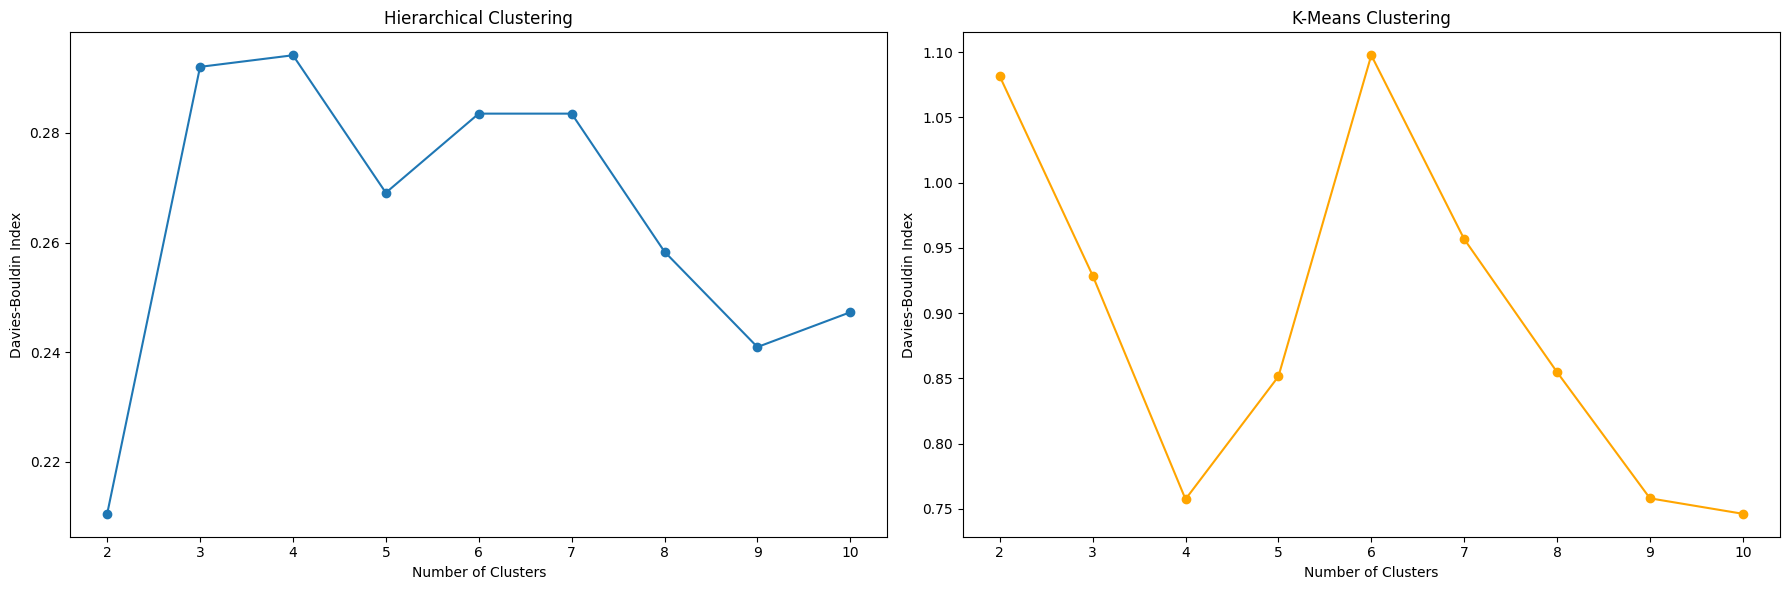

In [60]:
# Plot the Dunn Index for hierarchical clustering
fig, ax = plt.subplots(1, 2, figsize=(18, 6))  # Create 3 subplots for hierarchical, K-Means, and DBSCAN

# Hierarchical Clustering Dunn Index
ax[0].plot(cluster_range, hierarchical_db_scores, marker='o', label='Hierarchical')
ax[0].set_title('Hierarchical Clustering')
ax[0].set_xlabel('Number of Clusters')
ax[0].set_ylabel('Davies-Bouldin Index')


ax[1].plot(cluster_range, kmeans_db_scores, marker='o', color='orange', label='K-Means')
ax[1].set_title('K-Means Clustering')
ax[1].set_xlabel('Number of Clusters')
ax[1].set_ylabel('Davies-Bouldin Index')


plt.tight_layout()
plt.show()

In [36]:
corpus.idx2lexunit(5)

('alors', 'ADV')

In [61]:
import numpy as np
from scipy.spatial.distance import pdist
from scipy.cluster.hierarchy import linkage
from sklearn.metrics import davies_bouldin_score

types_of_matrix = ["precision", "coverage", "PMI", "tf-idf", "geometric_mean"]
link = ['single', 'average', 'complete']
red_dims = {}
for type_of_matrix in types_of_matrix:
    red_dims[type_of_matrix] = {}
    with open(f"{type_of_matrix}_reduced_dims.npy", 'rb') as f:
        X = np.load(f)
    red_dims[type_of_matrix]['cosine']= {}
    distance_matrix = pdist(X, metric="cosine")
    for i in range(len(link)):
        red_dims[type_of_matrix]['cosine'][link[i]] = {}
        linked = linkage(
            distance_matrix, method=link[i], optimal_ordering=True
        )
        for h in cluster_range:
            labels = fcluster(linked, h, criterion='maxclust')
            clusters = [X[labels == j] for j in np.unique(labels)]
            score = davies_bouldin_score(X, labels)
            red_dims[type_of_matrix]['cosine'][link[i]][h] = score

In [62]:
link = ['single', 'average', 'ward', 'complete', 'centroid']
for type_of_matrix in types_of_matrix:
    with open(f"{type_of_matrix}_reduced_dims.npy", 'rb') as f:
        X = np.load(f)
    red_dims[type_of_matrix]['euclidean']= {}
    distance_matrix = pdist(X, metric="euclidean")
    for i in range(len(link)):
        red_dims[type_of_matrix]['euclidean'][link[i]] = {}
        linked = linkage(
            distance_matrix, method=link[i], optimal_ordering=True
        )  
        for h in cluster_range:
            labels = fcluster(linked, h, criterion='maxclust')
            clusters = [X[labels == j] for j in np.unique(labels)]
            score = davies_bouldin_score(X, labels) 
            red_dims[type_of_matrix]['euclidean'][link[i]][h] = score

In [63]:
import numpy as np
from scipy.spatial.distance import pdist
from scipy.cluster.hierarchy import linkage
types_of_matrix = ["precision", "coverage", "PMI", "tf-idf", "geometric_mean"]
link = ['single', 'average', 'complete']
orig_dims = {}
for type_of_matrix in types_of_matrix:
    orig_dims[type_of_matrix] = {}
    with open(f"{type_of_matrix}_orig_dims.npy", 'rb') as f:
        X = np.load(f)
    orig_dims[type_of_matrix]['cosine']= {}
    distance_matrix = pdist(X, metric="cosine")
    for i in range(len(link)):
        orig_dims[type_of_matrix]['cosine'][link[i]] = {}
        linked = linkage(
            distance_matrix, method=link[i], optimal_ordering=True
        )
        for h in cluster_range:
            labels = fcluster(linked, h, criterion='maxclust')
            clusters = [X[labels == j] for j in np.unique(labels)]
            score = davies_bouldin_score(X, labels) 
            orig_dims[type_of_matrix]['cosine'][link[i]][h] = score

In [64]:
link = ['single', 'average', 'ward', 'complete', 'centroid']
for type_of_matrix in types_of_matrix:
    with open(f"{type_of_matrix}_orig_dims.npy", 'rb') as f:
        X = np.load(f)
    orig_dims[type_of_matrix]['euclidean']= {}
    distance_matrix = pdist(X, metric="euclidean")
    for i in range(len(link)):
        orig_dims[type_of_matrix]['euclidean'][link[i]] = {}
        linked = linkage(
            distance_matrix, method=link[i], optimal_ordering=True
        )  
        for h in cluster_range:
            labels = fcluster(linked, h, criterion='maxclust')
            clusters = [X[labels == j] for j in np.unique(labels)]
            score = davies_bouldin_score(X, labels)  
            orig_dims[type_of_matrix]['euclidean'][link[i]][h] = score

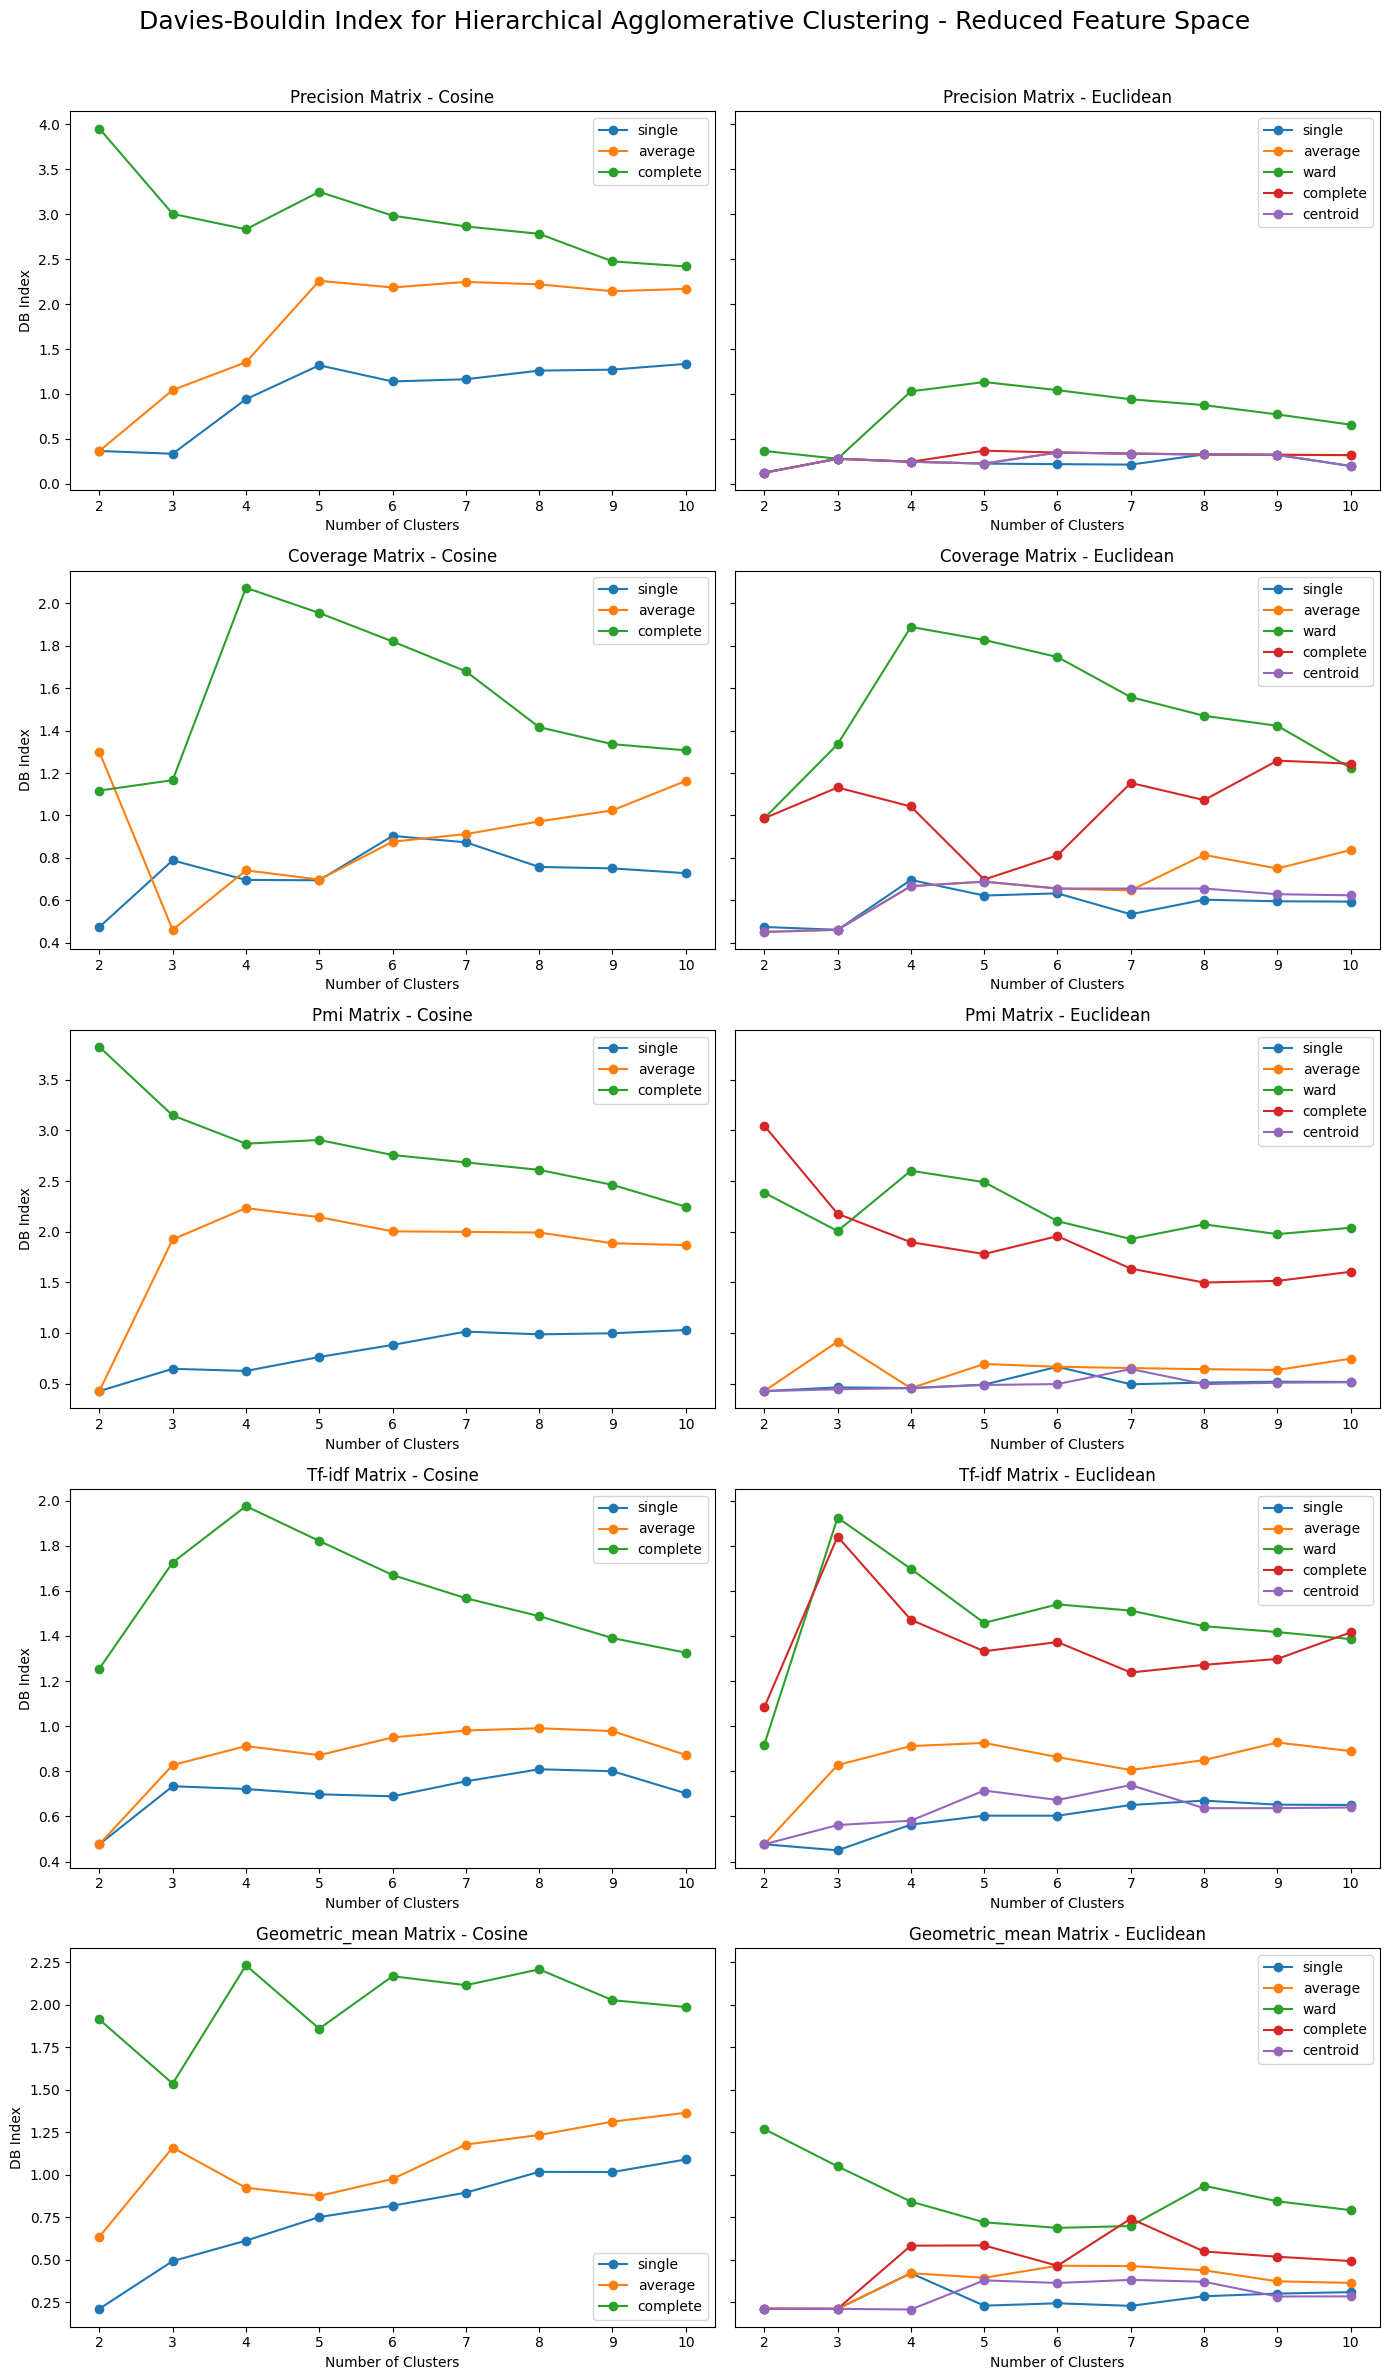

In [65]:
import matplotlib.pyplot as plt

matrix_types = list(red_dims.keys())
n_types = len(matrix_types)
fig, axes = plt.subplots(n_types, 2, figsize=(14, 5 * n_types), sharey='row')
fig.suptitle("Davies-Bouldin Index for Hierarchical Agglomerative Clustering - Reduced Feature Space", fontsize=18)

for row, matrix_type in enumerate(matrix_types):
    metrics = red_dims[matrix_type]
    for col, metric in enumerate(['cosine', 'euclidean']):
        ax = axes[row, col] if n_types > 1 else axes[col]
        for linkage in metrics[metric]:
            dunn_scores = [metrics[metric][linkage].get(k, float('nan')) for k in cluster_range]
            ax.plot(cluster_range, dunn_scores, marker='o', label=linkage)
        ax.set_title(f"{matrix_type.capitalize()} Matrix - {metric.capitalize()}")
        ax.set_xlabel("Number of Clusters")
        if col == 0:
            ax.set_ylabel("DB Index")
        ax.legend()
plt.tight_layout(rect=[0, 0.03, 1, 0.97])
plt.show()

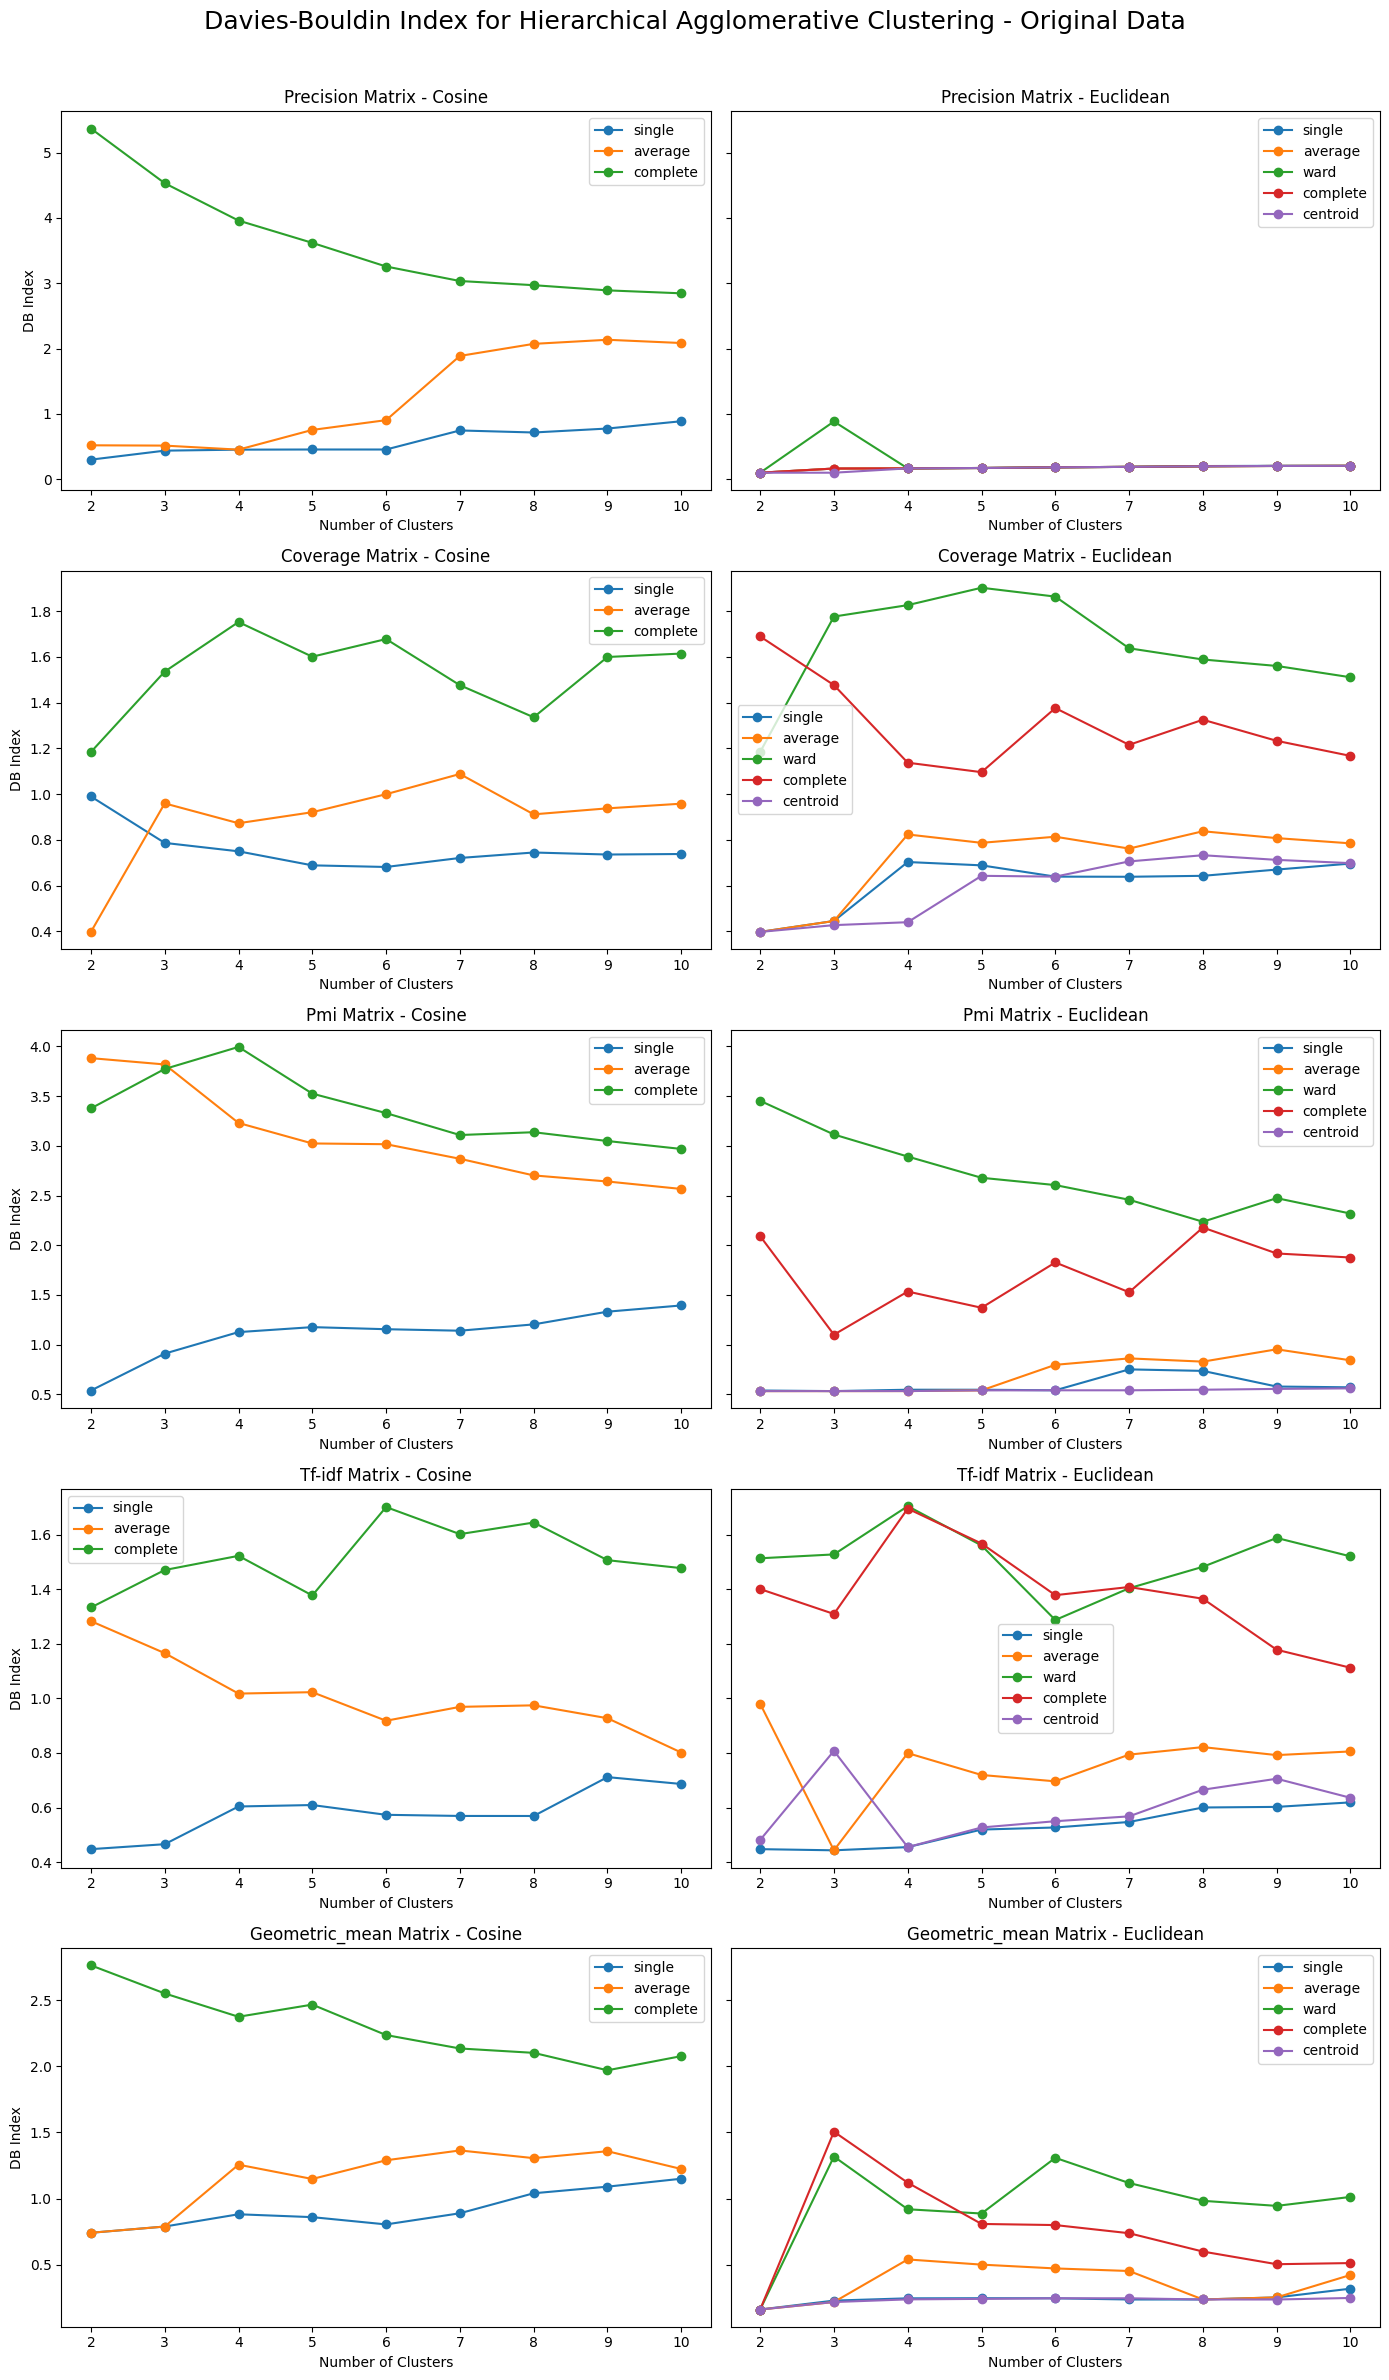

In [66]:
import matplotlib.pyplot as plt

matrix_types = list(orig_dims.keys())
n_types = len(matrix_types)
fig, axes = plt.subplots(n_types, 2, figsize=(14, 5 * n_types), sharey='row')
fig.suptitle("Davies-Bouldin Index for Hierarchical Agglomerative Clustering - Original Data", fontsize=18)

for row, matrix_type in enumerate(matrix_types):
    metrics = orig_dims[matrix_type]
    for col, metric in enumerate(['cosine', 'euclidean']):
        ax = axes[row, col] if n_types > 1 else axes[col]
        for linkage in metrics[metric]:
            dunn_scores = [metrics[metric][linkage].get(k, float('nan')) for k in cluster_range]
            ax.plot(cluster_range, dunn_scores, marker='o', label=linkage)
        ax.set_title(f"{matrix_type.capitalize()} Matrix - {metric.capitalize()}")
        ax.set_xlabel("Number of Clusters")
        if col == 0:
            ax.set_ylabel("DB Index")
        ax.legend()
plt.tight_layout(rect=[0, 0.03, 1, 0.97])
plt.show()

In [67]:
from sklearn.cluster import KMeans
orig_dims = {}
for type_of_matrix in types_of_matrix:
    orig_dims[type_of_matrix] = {}
    with open(f"{type_of_matrix}_orig_dims.npy", 'rb') as f:
        X = np.load(f)
    for i in cluster_range:
        kmeans = KMeans(n_clusters=i, random_state=42)  # Initialize K-Means
        labels = kmeans.fit_predict(X)  # Fit and predict cluster labels
        clusters = [X[labels == j] for j in np.unique(labels)]  # Group data points into clusters
        score = davies_bouldin_score(X, labels)  # Calculate the DB Index
        orig_dims[type_of_matrix][i] = score

In [68]:
from sklearn.cluster import KMeans
red_dims = {}
for type_of_matrix in types_of_matrix:
    red_dims[type_of_matrix] = {}
    with open(f"{type_of_matrix}_reduced_dims.npy", 'rb') as f:
        X = np.load(f)
    for i in cluster_range:
        kmeans = KMeans(n_clusters=i, random_state=42)  # Initialize K-Means
        labels = kmeans.fit_predict(X)  # Fit and predict cluster labels
        clusters = [X[labels == j] for j in np.unique(labels)]  # Group data points into clusters
        score = davies_bouldin_score(X, labels)  # Calculate the DB Index
        red_dims[type_of_matrix][i] = score

In [ ]:
from sklearn.cluster import KMeans
red_dims = {}
for type_of_matrix in types_of_matrix:
    red_dims[type_of_matrix] = {}
    with open(f"{type_of_matrix}_reduced_dims.npy", 'rb') as f:
        X = np.load(f)
    for i in cluster_range:
        kmeans = KMeans(n_clusters=i, random_state=42)  # Initialize K-Means
        labels = kmeans.fit_predict(X)  # Fit and predict cluster labels
        clusters = [X[labels == j] for j in np.unique(labels)]  # Group data points into clusters
        score = davies_bouldin_score(X, labels)  # Calculate the DB Index
        red_dims[type_of_matrix][i] = score

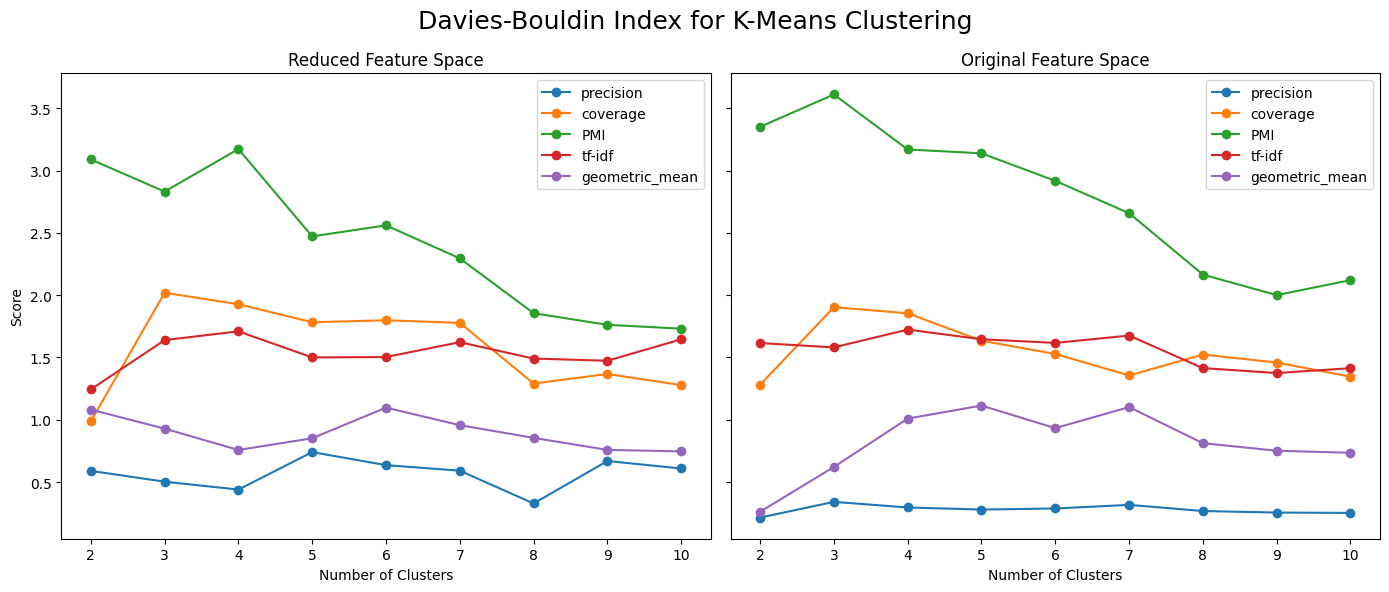

In [68]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)
titles = ["Reduced Feature Space", "Original Feature Space"]
dicts = [red_dims, orig_dims]
fig.suptitle("Davies-Bouldin Index for K-Means Clustering", fontsize=18)
for ax, metric_dict, title in zip(axes, dicts, titles):
    for matrix_type, values in metric_dict.items():
        scores = [values.get(k, float('nan')) for k in range(2, 11)]
        ax.plot(range(2, 11), scores, marker='o', label=matrix_type)
    ax.set_title(title)
    ax.set_xlabel("Number of Clusters")
    ax.legend()
axes[0].set_ylabel("Score")
plt.tight_layout()
plt.show()